In [137]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

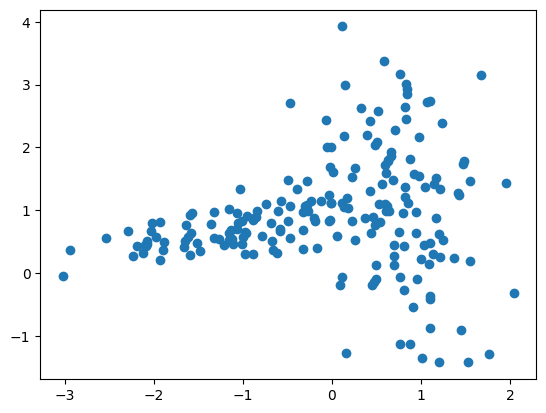

In [138]:
Xc_2,_= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])

Initialize K centroids

In [139]:
points = Xc_2
def init_centroids(amount, is_random = True, points = None):
    if is_random:
        return points [np.random.choice(len(points), amount)]
    else:
        centroids = np.array ([(0,0), (10,10), (20,20), (30,30) ])
        return centroids[:amount]

centroids = init_centroids(4, is_random= True, points = points)
print (centroids)


[[ 0.25989257  1.67926203]
 [-0.78887301  0.58891079]
 [-1.3520205   0.77563231]
 [ 0.05188115  0.58999866]]


Assign every point to closest centroid

In [140]:
def compute_distances(samples, centroids):
    return np.array([np.apply_along_axis(np.linalg.norm, 1, samples-c) for c in centroids])

compute_distances(points, centroids)

array([[2.87399312, 0.80452898, 0.46608335, 1.20999163, 1.64699573,
        2.36026534, 1.44589687, 1.93757588, 1.49132562, 0.53229725,
        0.58033116, 1.75013097, 0.96870994, 0.62105632, 2.63705602,
        2.73864596, 0.25523414, 1.71647378, 2.66137906, 0.92584515,
        2.44632121, 1.45411315, 0.64672093, 1.14556777, 1.45651392,
        1.81918459, 1.34083094, 3.23579752, 2.2328602 , 2.21313768,
        1.2472533 , 1.75346324, 1.36068918, 1.84868562, 2.60508898,
        0.97551252, 3.34840827, 2.6614793 , 1.51286981, 1.21169463,
        3.70485854, 0.94693969, 0.6775534 , 3.31928056, 1.108947  ,
        1.60628774, 2.74608085, 0.91901077, 3.11609685, 0.14661783,
        2.02141109, 1.81270059, 1.2122752 , 1.29671109, 1.32765473,
        1.22802924, 2.63058314, 1.96458526, 0.40376167, 1.7299791 ,
        1.56797353, 1.50944555, 1.79478906, 1.33507266, 0.98966043,
        0.7263048 , 1.29008494, 0.72557581, 1.28868945, 2.85040203,
        1.62768688, 0.28131336, 1.30843169, 2.69

In [141]:
def compute_closest_centroids(centroids):
    all_distances = compute_distances(points, centroids)
    closest_centroids = np.apply_along_axis(np.argmin,0,all_distances)
    return closest_centroids

closest_centroids = compute_closest_centroids(centroids)
print ('closest_centroids:\n',closest_centroids)

closest_centroids:
 [3 3 0 3 1 2 0 2 1 0 3 3 0 3 2 2 0 3 2 0 2 3 3 3 3 3 1 3 2 3 0 2 1 1 2 3 3
 2 1 0 2 1 0 3 3 1 2 3 3 0 3 3 0 1 0 0 2 2 0 0 3 2 3 2 1 3 1 0 1 3 3 0 1 3
 2 3 3 0 0 2 3 1 2 2 0 3 3 0 0 0 2 0 0 0 1 3 3 0 3 0 0 2 3 0 2 2 2 1 1 0 2
 0 2 0 2 3 0 0 1 0 3 0 0 1 3 0 2 0 3 2 3 0 3 0 0 3 3 0 0 3 3 3 0 1 0 3 3 2
 0 2 2 3 0 1 3 1 0 2 3 0 3 1 3 3 2 0 3 0 1 1 3 3 3 3 3 2 1 3 2 1 2 0 0 3 3
 0 0 0 2 3 3 0 2 2 0 0 0 3 3 0]


Compute new centroids as means of samples assigned to corresponding

In [142]:
def update_centroids(points, closest_centroids, k):
    new_centroids = []
    for i in range(k):
        cluster_points = points[closest_centroids == i]
        if len(cluster_points) == 0:
            new_centroids.append(points[np.random.randint(len(points))])
        else:
            new_centroids.append(np.mean(cluster_points, axis=0))
    return np.array(new_centroids)

Implement cost

In [143]:
def J(centroids, closest_centroids):
    all_dist = []
    for c_index in set(closest_centroids):
        assigned_samples = points[np.where(closest_centroids==c_index)]
        distances = np.sum((assigned_samples - centroids[c_index])**2, axis=1)
        all_dist.append(np.sum(distances))
    m = len(closest_centroids)
    return 1/m* np.sum(all_dist)

closest_centroids = compute_closest_centroids(centroids)
print(J(centroids, closest_centroids))

0.8342083458475165


Iterate setps 2,3 till cost is stabile

In [144]:
def kmeans(points, k, max_iters=100, tol=1e-4):
    centroids = init_centroids(k, is_random=True, points=points)
    prev_cost = float('inf')
    for iteration in range(max_iters):
        closest_centroids = compute_closest_centroids(centroids)
        cost = J(centroids, closest_centroids)
        if abs(prev_cost - cost) < tol:
            print(f"Converged at iteration {iteration}")
            break
        centroids = update_centroids(points, closest_centroids, k)
        prev_cost = cost
    return centroids, closest_centroids
kmeans(points, 4)

Converged at iteration 9


(array([[ 0.95768935, -0.28670368],
        [ 0.63968991,  2.44940281],
        [ 0.41052221,  1.10355754],
        [-1.36417308,  0.62875254]]),
 array([0, 2, 2, 2, 3, 3, 1, 3, 3, 1, 2, 0, 1, 2, 3, 3, 2, 0, 3, 2, 3, 0,
        2, 2, 0, 0, 3, 0, 3, 0, 2, 3, 3, 3, 3, 2, 0, 3, 3, 1, 3, 2, 2, 0,
        2, 3, 3, 2, 0, 2, 0, 0, 1, 3, 1, 2, 3, 3, 2, 1, 0, 3, 0, 3, 3, 2,
        3, 2, 3, 0, 0, 2, 3, 0, 3, 2, 2, 1, 1, 3, 0, 3, 3, 3, 1, 2, 2, 1,
        2, 1, 3, 1, 2, 1, 3, 0, 0, 1, 2, 1, 1, 3, 0, 2, 3, 3, 3, 3, 3, 2,
        3, 1, 3, 1, 3, 2, 1, 1, 3, 1, 2, 1, 1, 3, 0, 2, 3, 2, 2, 3, 2, 1,
        2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 3, 2, 0, 2, 3, 2, 3, 3, 0, 2, 3,
        2, 3, 2, 3, 0, 1, 2, 3, 2, 2, 3, 1, 0, 1, 3, 3, 2, 0, 2, 0, 0, 3,
        3, 0, 3, 3, 3, 2, 1, 2, 2, 2, 2, 1, 3, 2, 2, 1, 3, 3, 2, 1, 1, 0,
        2, 2]))

Select the best clustering (with the least cost) from 100 results computed with random centroid initializations

In [145]:
def run_kmeans_multiple(points, k, n_runs=100):
    best_cost = float('inf')
    best_centroids = None
    best_labels = None

    for i in range(n_runs):
        centroids = init_centroids(k, is_random=True, points=points)

        centroids, labels = kmeans(points, k)

        cost = J(centroids, labels)

        if cost < best_cost:
            best_cost = cost
            best_centroids = centroids
            best_labels = labels

    return best_centroids, best_labels, best_cost
run_kmeans_multiple(points, 4)

Converged at iteration 6
Converged at iteration 8
Converged at iteration 9
Converged at iteration 7
Converged at iteration 15
Converged at iteration 7
Converged at iteration 6
Converged at iteration 8
Converged at iteration 9
Converged at iteration 13
Converged at iteration 13
Converged at iteration 7
Converged at iteration 9
Converged at iteration 6
Converged at iteration 13
Converged at iteration 7
Converged at iteration 6
Converged at iteration 8
Converged at iteration 10
Converged at iteration 11
Converged at iteration 6
Converged at iteration 8
Converged at iteration 11
Converged at iteration 10
Converged at iteration 14
Converged at iteration 16
Converged at iteration 9
Converged at iteration 9
Converged at iteration 17
Converged at iteration 11
Converged at iteration 7
Converged at iteration 5
Converged at iteration 4
Converged at iteration 9
Converged at iteration 14
Converged at iteration 18
Converged at iteration 11
Converged at iteration 10
Converged at iteration 10
Converge

(array([[ 0.0467027 ,  0.99993105],
        [ 0.96220912, -0.18860474],
        [-1.46901201,  0.59888478],
        [ 0.76885808,  2.14333659]]),
 array([1, 0, 3, 1, 2, 2, 3, 2, 2, 3, 0, 1, 3, 0, 2, 2, 0, 1, 2, 3, 2, 1,
        0, 0, 1, 1, 0, 1, 2, 1, 3, 2, 2, 2, 2, 0, 1, 2, 2, 3, 2, 0, 0, 1,
        0, 2, 2, 0, 1, 0, 1, 1, 3, 2, 3, 3, 2, 2, 0, 3, 1, 2, 1, 2, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 1, 2, 0, 0, 3, 3, 2, 1, 0, 2, 2, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 2, 1, 1, 3, 0, 3, 3, 2, 1, 0, 2, 2, 2, 2, 2, 3,
        2, 3, 2, 3, 2, 0, 3, 3, 2, 3, 1, 3, 3, 2, 1, 0, 2, 3, 0, 2, 0, 3,
        0, 0, 0, 1, 0, 3, 0, 1, 0, 0, 0, 2, 3, 1, 0, 2, 0, 2, 2, 1, 0, 0,
        0, 2, 3, 2, 1, 3, 0, 2, 1, 0, 2, 3, 1, 3, 2, 2, 0, 1, 0, 1, 1, 2,
        2, 1, 2, 0, 2, 3, 3, 0, 1, 3, 0, 3, 2, 0, 0, 3, 2, 2, 3, 3, 3, 1,
        0, 3]),
 np.float64(0.4576916248652856))

Visualize results (clusters, centroids) for K=4.

Converged at iteration 5


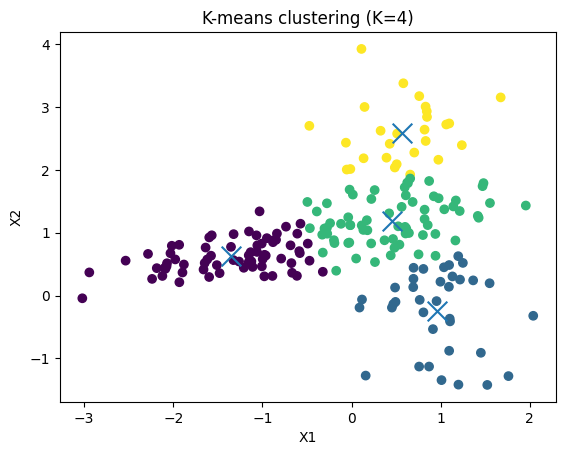

In [146]:
centroids, labels = kmeans(points, k=4)
def plot_kmeans(points, labels, centroids):
    plt.figure()
    plt.scatter(points[:, 0], points[:, 1], c=labels)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=200)

    plt.title("K-means clustering (K=4)")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()
plot_kmeans(points, labels, centroids)